# Telecommunication Supply Chain & Sales Analysis

## Executive Summary

This project analyzes **2,000 sales transactions** from a global telecommunications equipment supplier spanning **January 2023 to June 2025**. The analysis covers:
- **Sales Performance** — Revenue trends, top products, regional & channel analysis
- **Supply Chain Efficiency** — Delivery performance, supplier lead times, logistics bottlenecks
- **Profitability Analysis** — Margin decomposition by product, segment, and region
- **Inventory Management** — Stock level adequacy, reorder point alignment

### Key Findings at a Glance
| Metric | Value |
|--------|-------|
| Total Revenue | **$76.3M** |
| Total Profit | **$32.1M** |
| Overall Margin | **42.1%** |
| On-Time Delivery Rate | **65.0%** |
| Avg Lead Time | **~24 days** |
| Top Category | **Network Equipment** (43.3% of revenue) |
| Most Profitable Channel | **Direct Sales** (47.8% margin) |

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Load dataset
df = pd.read_csv('../data/telco_supply_chain_sales.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'], errors='coerce')

print(f'Shape: {df.shape}')
print(f'Date Range: {df["Order_Date"].min().date()} to {df["Order_Date"].max().date()}')
df.head(3)

Shape: (2000, 23)
Date Range: 2023-01-01 to 2025-06-01


,Order_ID,Order_Date,Delivery_Date,Product_Category,Product_Name,Quantity,Unit_Cost,Unit_Price,Discount_Pct,Revenue,...,Lead_Time_Days,Delivery_Status,Supplier_Name,Supplier_Region,Warehouse_Location,Customer_Segment,Sales_Channel,Inventory_Level,Reorder_Point,Safety_Stock
0,ORD-00001,2023-01-31,2023-02-16,Antennas,Omni 5G Antenna,1,80.0,190.0,10,171.0,...,16,On Time,Samsung Networks,Asia,"Dallas, TX",Individual,Direct Sales,287,26,30
1,ORD-00002,2023-10-12,2023-11-03,Antennas,Parabolic Dish 0.6m,2,150.0,320.0,0,640.0,...,22,On Time,Ericsson AB,Europe,"Los Angeles, CA",Individual,Retail Partner,194,23,21
2,ORD-00003,2024-07-19,2024-08-19,Batteries & Power,Small Cell UPS,10,450.0,820.0,0,8200.0,...,31,Damaged,Juniper Networks,North America,"Dallas, TX",Individual,Direct Sales,295,26,12


---
## 1. Sales Performance Analysis

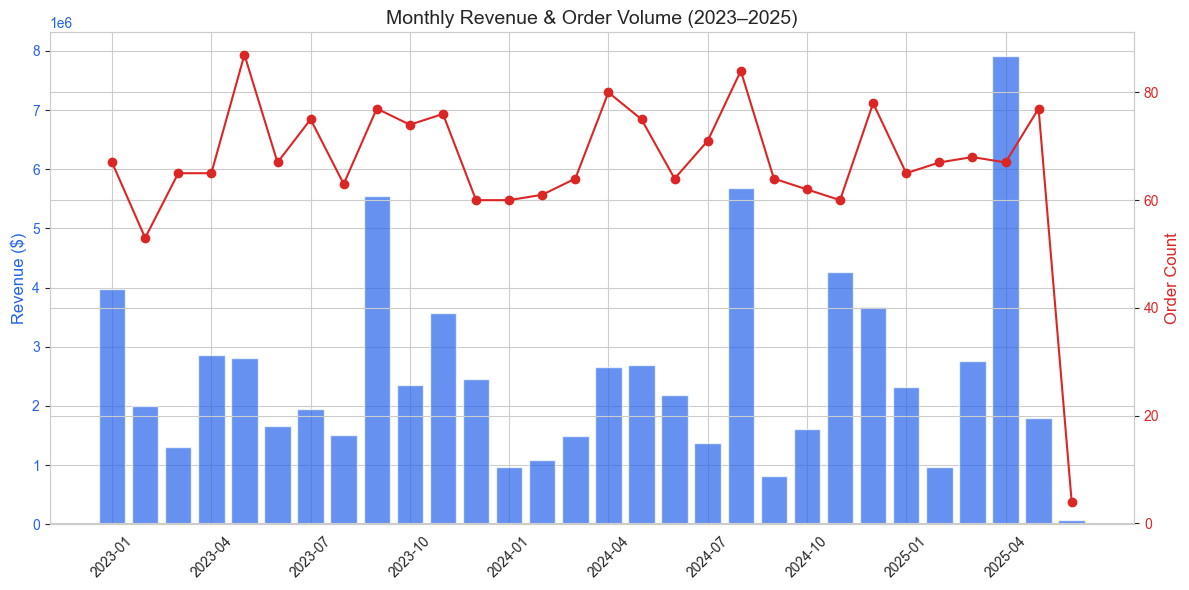

In [2]:
## 1a. Monthly Revenue Trend

df['YearMonth'] = df['Order_Date'].dt.to_period('M')
monthly = df.groupby('YearMonth').agg(Revenue=('Revenue', 'sum'), Orders=('Order_ID', 'count')).reset_index()
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

fig, ax1 = plt.subplots()
color1, color2 = '#2563EB', '#DC2626'
ax1.bar(monthly['YearMonth'], monthly['Revenue'], color=color1, alpha=0.7, label='Revenue')
ax1.set_ylabel('Revenue ($)', color=color1); ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(range(0, len(monthly), 3)); ax1.set_xticklabels(monthly['YearMonth'][::3], rotation=45)
ax2 = ax1.twinx()
ax2.plot(monthly['YearMonth'], monthly['Orders'], color=color2, marker='o', label='Order Volume')
ax2.set_ylabel('Order Count', color=color2); ax2.tick_params(axis='y', labelcolor=color2)
plt.title('Monthly Revenue & Order Volume (2023–2025)')
fig.tight_layout(); plt.savefig('../visuals/monthly_revenue_trend.png', dpi=150, bbox_inches='tight'); plt.show()

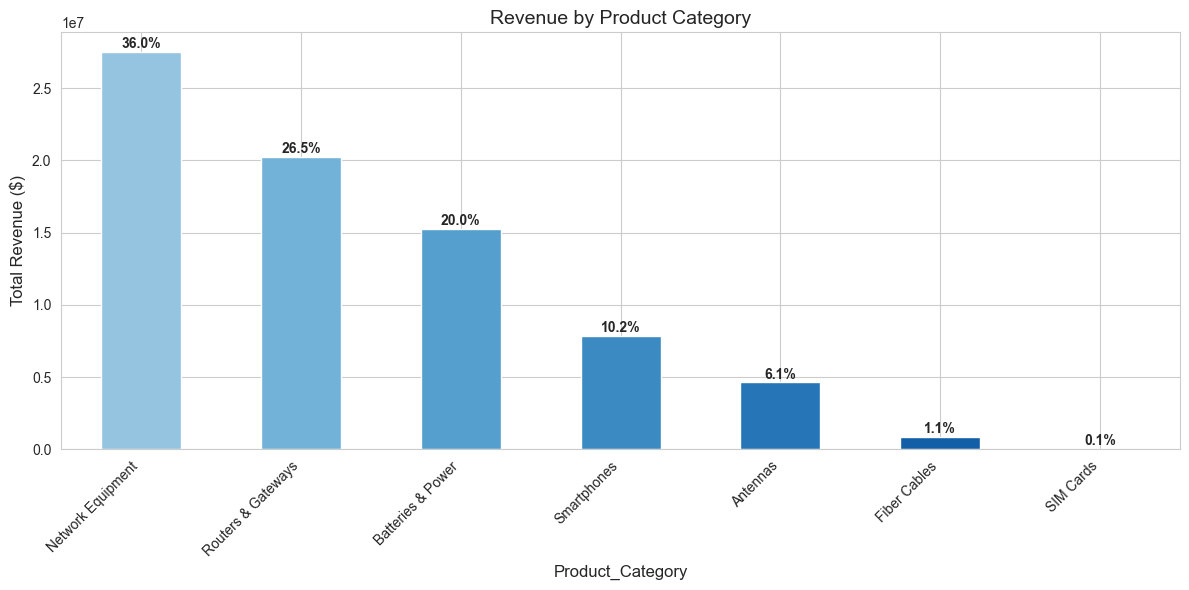

Revenue by Category:
  Network Equipment    $27,488,920.00  ( 36.0%)
  Routers & Gateways   $20,248,066.75  ( 26.5%)
  Batteries & Power    $15,258,420.00  ( 20.0%)
  Smartphones          $7,822,616.20  ( 10.2%)
  Antennas             $4,629,062.25  (  6.1%)
  Fiber Cables         $840,949.80  (  1.1%)
  SIM Cards            $ 44,203.67  (  0.1%)


In [3]:
## 1b. Revenue by Product Category

cat_rev = df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(cat_rev)))
ax = cat_rev.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Revenue by Product Category')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(cat_rev):
    pct = v / cat_rev.sum() * 100
    ax.text(i, v + cat_rev.max() * 0.01, f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=10)
plt.tight_layout(); plt.savefig('../visuals/revenue_by_category.png', dpi=150, bbox_inches='tight'); plt.show()

print('Revenue by Category:')
for cat, rev in cat_rev.items():
    print(f'  {cat:20s} ${rev:>10,.2f}  ({rev/cat_rev.sum()*100:5.1f}%)')

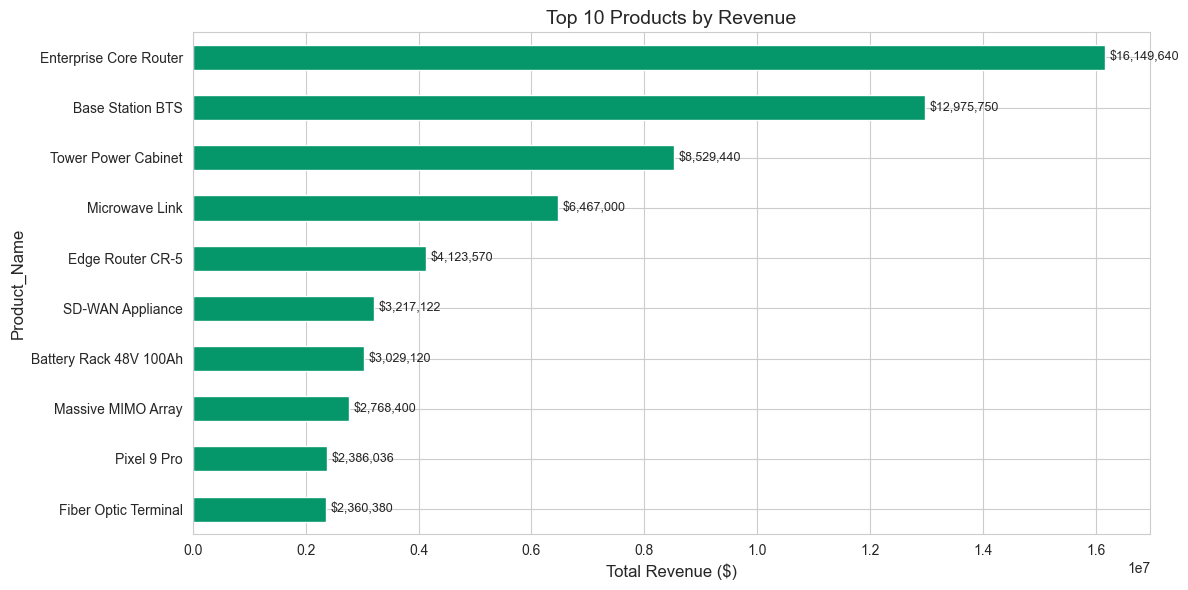

In [4]:
## 1c. Top 10 Products by Revenue

prod_rev = df.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False).head(10)
ax = prod_rev.plot(kind='barh', color='#059669', edgecolor='white')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue ($)')
ax.invert_yaxis()
for i, v in enumerate(prod_rev):
    ax.text(v + prod_rev.max() * 0.005, i, f'${v:,.0f}', va='center', fontsize=9)
plt.tight_layout(); plt.savefig('../visuals/top10_products.png', dpi=150, bbox_inches='tight'); plt.show()

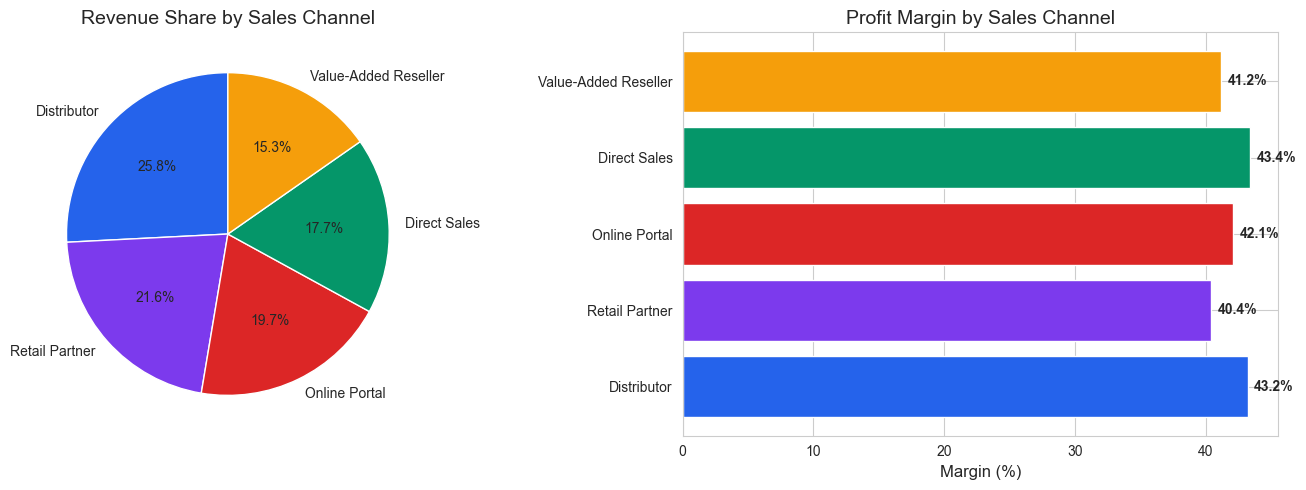

,Revenue,Profit,Orders,Margin
Sales_Channel,,,,
Distributor,19702857.43,8503842.13,415,43.2
Retail Partner,16450295.08,6644049.78,390,40.4
Online Portal,15009567.01,6319259.61,429,42.1
Direct Sales,13492709.68,5855887.98,386,43.4
Value-Added Reseller,11676809.47,4806724.37,380,41.2


In [5]:
## 1d. Sales Channel Performance

channel = df.groupby('Sales_Channel').agg(Revenue=('Revenue', 'sum'), Profit=('Profit', 'sum'), Orders=('Order_ID', 'count'))
channel['Margin'] = (channel['Profit'] / channel['Revenue'] * 100).round(1)
channel = channel.sort_values('Revenue', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2563EB', '#7C3AED', '#DC2626', '#059669', '#F59E0B']
ax1.pie(channel['Revenue'], labels=channel.index, autopct='%1.1f%%', colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'})
ax1.set_title('Revenue Share by Sales Channel')

bars = ax2.barh(channel.index, channel['Margin'], color=colors)
ax2.set_title('Profit Margin by Sales Channel')
ax2.set_xlabel('Margin (%)')
for bar, m in zip(bars, channel['Margin']):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{m}%', va='center', fontweight='bold')
plt.tight_layout(); plt.savefig('../visuals/channel_performance.png', dpi=150, bbox_inches='tight'); plt.show()

channel[['Revenue', 'Profit', 'Orders', 'Margin']]

---
## 2. Supply Chain Efficiency Analysis

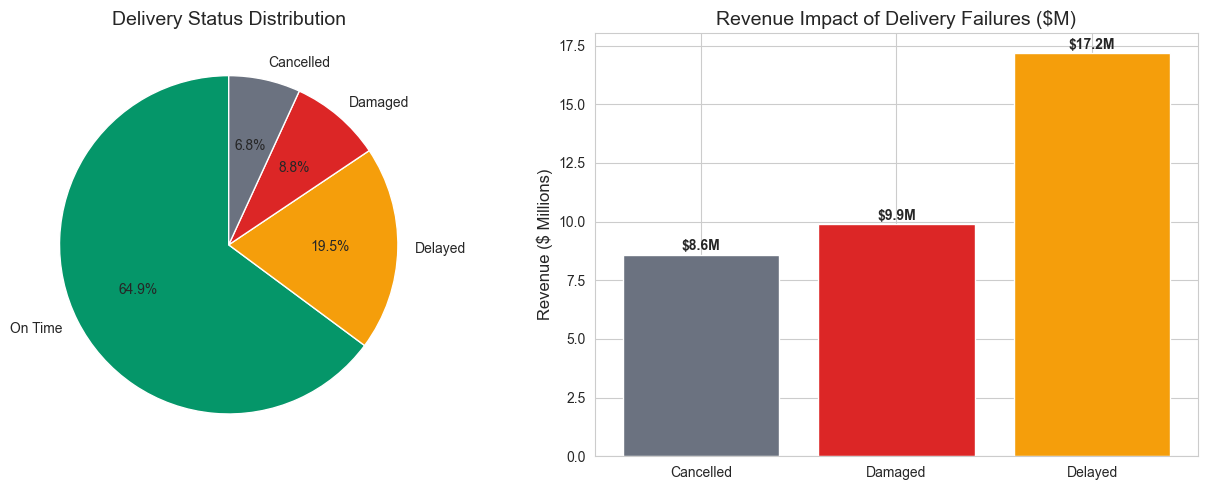

On-Time Delivery Rate: 64.8%
Delayed Orders: 19.6% (391 orders)
Damaged in Transit: 8.8%
Cancelled Orders: 6.8%


In [6]:
## 2a. Delivery Status Breakdown

status_counts = df['Delivery_Status'].value_counts()
colors = {'On Time': '#059669', 'Delayed': '#F59E0B', 'Damaged': '#DC2626', 'Cancelled': '#6B7280'}
status_pct = (status_counts / status_counts.sum() * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
wedges, texts, autotexts = ax1.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
                                    colors=[colors[s] for s in status_counts.index], startangle=90, wedgeprops={'edgecolor': 'white'})
ax1.set_title('Delivery Status Distribution')

status_rev_loss = df[df['Delivery_Status'] != 'On Time'].groupby('Delivery_Status')['Revenue'].sum()
bars = ax2.bar(status_rev_loss.index, status_rev_loss / 1e6, color=[colors[s] for s in status_rev_loss.index], edgecolor='white')
ax2.set_title('Revenue Impact of Delivery Failures ($M)')
ax2.set_ylabel('Revenue ($ Millions)')
for bar, v in zip(bars, status_rev_loss):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'${v/1e6:.1f}M', ha='center', fontweight='bold')
plt.tight_layout(); plt.savefig('../visuals/delivery_status.png', dpi=150, bbox_inches='tight'); plt.show()

print(f'On-Time Delivery Rate: {status_pct["On Time"]}%')
print(f'Delayed Orders: {status_pct["Delayed"]}% ({status_counts["Delayed"]} orders)')
print(f'Damaged in Transit: {status_pct["Damaged"]}%')
print(f'Cancelled Orders: {status_pct["Cancelled"]}%')

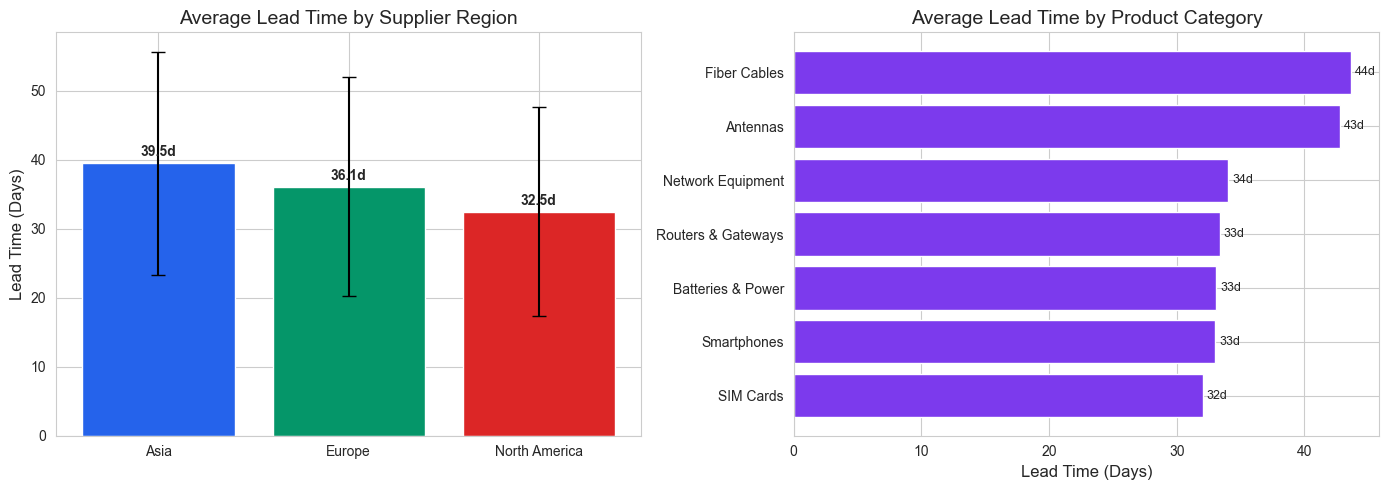

,mean,median,std
Supplier_Region,,,
Asia,39.5,39.0,16.2
Europe,36.1,36.0,15.9
North America,32.5,32.0,15.2


In [7]:
## 2b. Average Lead Time by Supplier Region & Product Category

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

region_lt = df.groupby('Supplier_Region')['Lead_Time_Days'].agg(['mean', 'median', 'std']).round(1)
colors_region = ['#2563EB', '#059669', '#DC2626']
bars = ax1.bar(region_lt.index, region_lt['mean'], color=colors_region, edgecolor='white', yerr=region_lt['std'], capsize=5)
ax1.set_title('Average Lead Time by Supplier Region')
ax1.set_ylabel('Lead Time (Days)')
for bar, v in zip(bars, region_lt['mean']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{v}d', ha='center', fontweight='bold')

cat_lt = df.groupby('Product_Category')['Lead_Time_Days'].mean().sort_values()
ax2.barh(cat_lt.index, cat_lt.values, color='#7C3AED', edgecolor='white')
ax2.set_title('Average Lead Time by Product Category')
ax2.set_xlabel('Lead Time (Days)')
for i, v in enumerate(cat_lt):
    ax2.text(v + 0.3, i, f'{v:.0f}d', va='center', fontsize=9)
plt.tight_layout(); plt.savefig('../visuals/lead_time_analysis.png', dpi=150, bbox_inches='tight'); plt.show()

region_lt

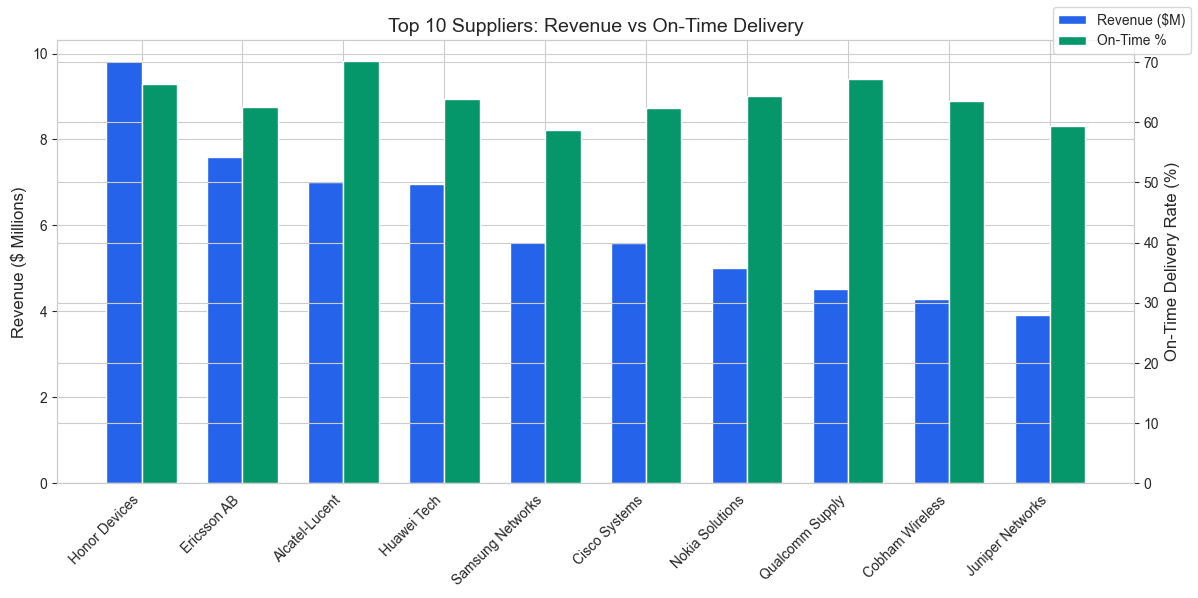

,Total_Revenue,Avg_Lead_Time,On_Time_Rate,Orders
Supplier_Name,,,,
Honor Devices,9815891.6,39.3,66.4,128
Ericsson AB,7592375.7,36.8,62.6,131
Alcatel-Lucent,7017931.8,36.9,70.1,134
Huawei Tech,6958093.4,39.0,63.8,127
Samsung Networks,5614123.5,39.0,58.7,143
Cisco Systems,5585650.7,31.9,62.4,141
Nokia Solutions,5010880.6,36.1,64.3,154
Qualcomm Supply,4518257.4,31.5,67.2,119
Cobham Wireless,4291671.0,36.6,63.6,118


In [8]:
## 2c. Supplier Performance

supplier_perf = df.groupby('Supplier_Name').agg(
    Total_Revenue=('Revenue', 'sum'),
    Avg_Lead_Time=('Lead_Time_Days', 'mean'),
    On_Time_Rate=('Delivery_Status', lambda x: (x == 'On Time').mean() * 100),
    Orders=('Order_ID', 'count')
).round(1).sort_values('Total_Revenue', ascending=False)

top_suppliers = supplier_perf.head(10)
fig, ax1 = plt.subplots()
x = np.arange(len(top_suppliers))
w = 0.35
bars1 = ax1.bar(x - w/2, top_suppliers['Total_Revenue'] / 1e6, w, label='Revenue ($M)', color='#2563EB', edgecolor='white')
ax2 = ax1.twinx()
bars2 = ax2.bar(x + w/2, top_suppliers['On_Time_Rate'], w, label='On-Time %', color='#059669', edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(top_suppliers.index, rotation=45, ha='right')
ax1.set_ylabel('Revenue ($ Millions)')
ax2.set_ylabel('On-Time Delivery Rate (%)')
ax1.set_title('Top 10 Suppliers: Revenue vs On-Time Delivery')
fig.legend(loc='upper right'); plt.tight_layout()
plt.savefig('../visuals/supplier_performance.png', dpi=150, bbox_inches='tight'); plt.show()

top_suppliers[['Total_Revenue', 'Avg_Lead_Time', 'On_Time_Rate', 'Orders']].head(10)

---
## 3. Profitability Analysis

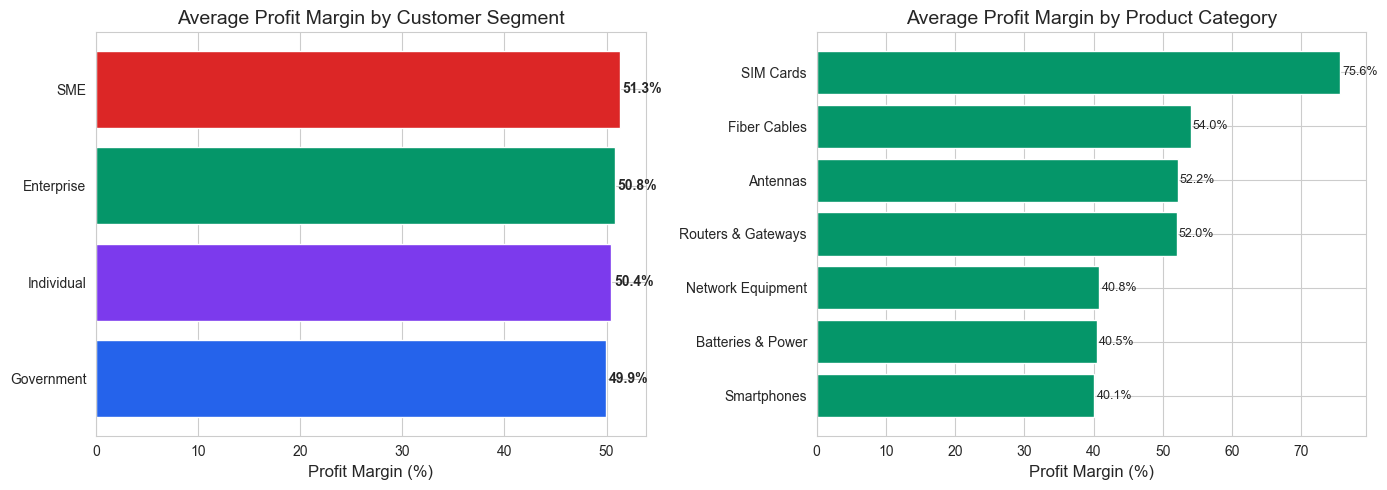

In [9]:
## 3a. Profit Margin by Customer Segment & Product Category

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

seg_margin = df.groupby('Customer_Segment')['Profit_Margin_Pct'].mean().sort_values()
colors_seg = ['#2563EB', '#7C3AED', '#059669', '#DC2626']
bars = ax1.barh(seg_margin.index, seg_margin.values, color=colors_seg, edgecolor='white')
ax1.set_title('Average Profit Margin by Customer Segment')
ax1.set_xlabel('Profit Margin (%)')
for bar, v in zip(bars, seg_margin):
    ax1.text(v + 0.3, bar.get_y() + bar.get_height()/2, f'{v:.1f}%', va='center', fontweight='bold')

cat_margin = df.groupby('Product_Category')['Profit_Margin_Pct'].mean().sort_values()
bars2 = ax2.barh(cat_margin.index, cat_margin.values, color='#059669', edgecolor='white')
ax2.set_title('Average Profit Margin by Product Category')
ax2.set_xlabel('Profit Margin (%)')
for bar, v in zip(bars2, cat_margin):
    ax2.text(v + 0.3, bar.get_y() + bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout(); plt.savefig('../visuals/profit_margins.png', dpi=150, bbox_inches='tight'); plt.show()

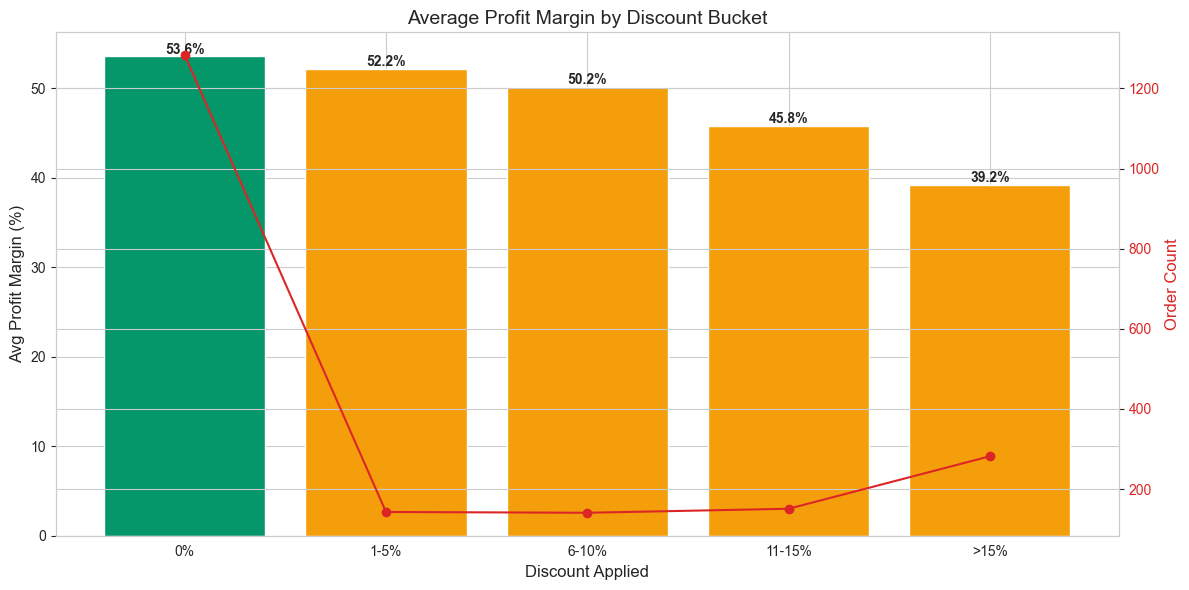

,Avg_Margin,Total_Revenue,Order_Count
Discount_Bucket,,,
0%,53.6,45263250.0,1283
1-5%,52.2,7550311.7,143
6-10%,50.2,9392084.1,141
11-15%,45.8,3285724.7,151
>15%,39.2,10840868.2,282


In [10]:
## 3b. Discount Impact on Profitability

df['Discount_Bucket'] = pd.cut(df['Discount_Pct'], bins=[-1, 0, 5, 10, 15, 100], labels=['0%', '1-5%', '6-10%', '11-15%', '>15%'])
discount_impact = df.groupby('Discount_Bucket', observed=True).agg(
    Avg_Margin=('Profit_Margin_Pct', 'mean'),
    Total_Revenue=('Revenue', 'sum'),
    Order_Count=('Order_ID', 'count')
).round(1)

fig, ax1 = plt.subplots()
bars = ax1.bar(discount_impact.index, discount_impact['Avg_Margin'],
               color=['#059669' if i == 0 else '#F59E0B' for i in range(len(discount_impact))], edgecolor='white')
ax1.set_title('Average Profit Margin by Discount Bucket')
ax1.set_xlabel('Discount Applied'); ax1.set_ylabel('Avg Profit Margin (%)')
for bar, v in zip(bars, discount_impact['Avg_Margin']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
ax2 = ax1.twinx()
ax2.plot(discount_impact.index, discount_impact['Order_Count'], color='#DC2626', marker='o', label='Order Count')
ax2.set_ylabel('Order Count', color='#DC2626'); ax2.tick_params(axis='y', labelcolor='#DC2626')
plt.tight_layout(); plt.savefig('../visuals/discount_impact.png', dpi=150, bbox_inches='tight'); plt.show()

discount_impact

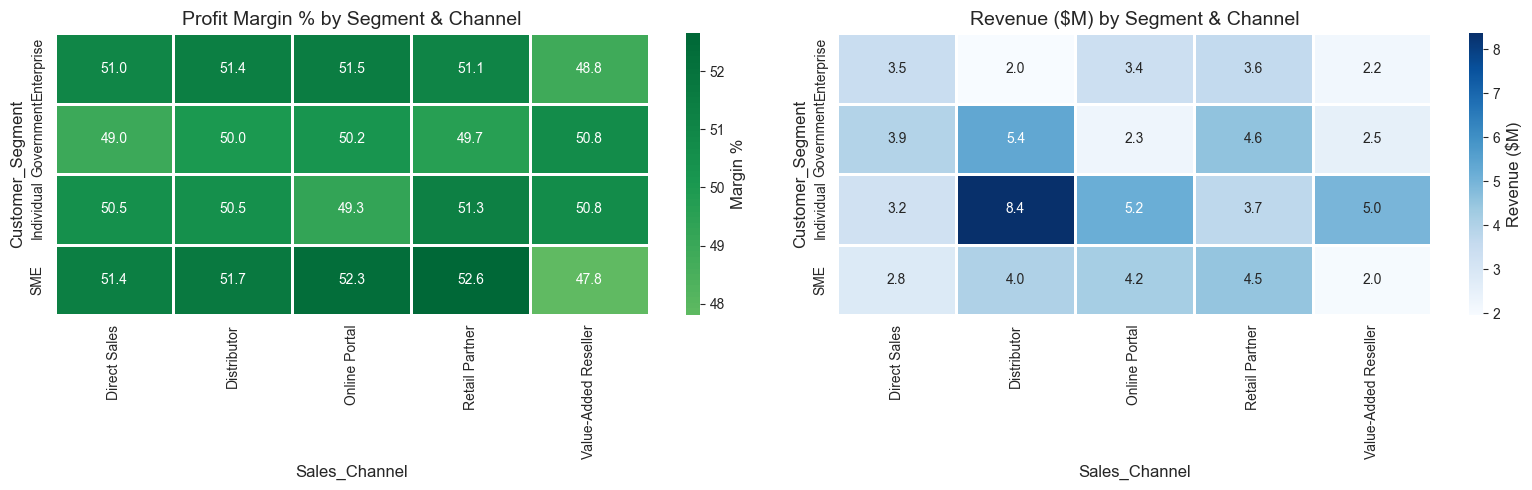

In [11]:
## 3c. Profitability Heatmap (Segment x Channel)

pivot_margin = df.pivot_table(values='Profit_Margin_Pct', index='Customer_Segment', columns='Sales_Channel', aggfunc='mean')
pivot_revenue = df.pivot_table(values='Revenue', index='Customer_Segment', columns='Sales_Channel', aggfunc='sum') / 1e6

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(pivot_margin, annot=True, fmt='.1f', cmap='RdYlGn', center=40, ax=ax1, linewidths=1, cbar_kws={'label': 'Margin %'})
ax1.set_title('Profit Margin % by Segment & Channel')
sns.heatmap(pivot_revenue, annot=True, fmt='.1f', cmap='Blues', ax=ax2, linewidths=1, cbar_kws={'label': 'Revenue ($M)'})
ax2.set_title('Revenue ($M) by Segment & Channel')
plt.tight_layout(); plt.savefig('../visuals/segment_channel_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 4. Inventory Management Analysis

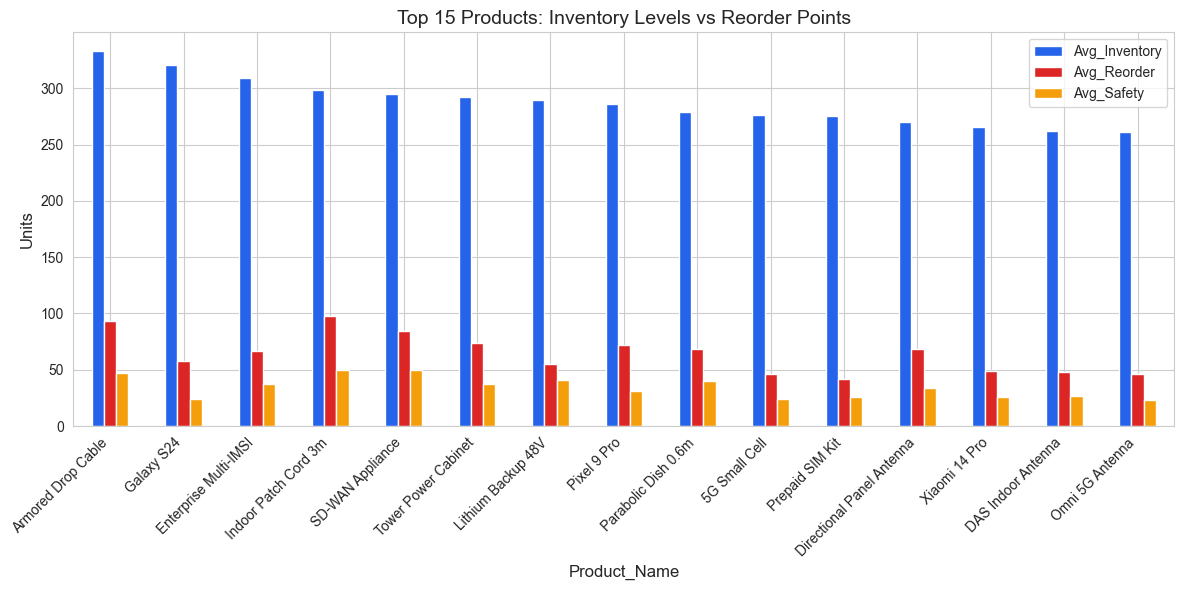

,Avg_Inventory,Avg_Reorder,Avg_Safety,Stock_Health,Status
Product_Name,,,,,
Armored Drop Cable,333.0,93.0,47.0,240.0,Healthy
Galaxy S24,321.0,58.0,24.0,263.0,Healthy
Enterprise Multi-IMSI,309.0,67.0,37.0,242.0,Healthy
Indoor Patch Cord 3m,298.0,98.0,50.0,200.0,Healthy
SD-WAN Appliance,295.0,84.0,50.0,211.0,Healthy
Tower Power Cabinet,292.0,74.0,37.0,218.0,Healthy
Lithium Backup 48V,290.0,55.0,41.0,235.0,Healthy
Pixel 9 Pro,286.0,72.0,31.0,214.0,Healthy
Parabolic Dish 0.6m,279.0,68.0,40.0,211.0,Healthy


In [12]:
## 4a. Inventory vs Reorder Point by Product

inv_status = df.groupby('Product_Name').agg(
    Avg_Inventory=('Inventory_Level', 'mean'),
    Avg_Reorder=('Reorder_Point', 'mean'),
    Avg_Safety=('Safety_Stock', 'mean')
).round(0).sort_values('Avg_Inventory', ascending=False).head(15)

inv_status['Stock_Health'] = inv_status['Avg_Inventory'] - inv_status['Avg_Reorder']
inv_status['Status'] = inv_status['Stock_Health'].apply(lambda x: 'Healthy' if x > 0 else 'Reorder Needed')

ax = inv_status[['Avg_Inventory', 'Avg_Reorder', 'Avg_Safety']].plot(kind='bar', color=['#2563EB', '#DC2626', '#F59E0B'], edgecolor='white')
plt.title('Top 15 Products: Inventory Levels vs Reorder Points')
plt.ylabel('Units'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig('../visuals/inventory_analysis.png', dpi=150, bbox_inches='tight'); plt.show()

inv_status.head(10)

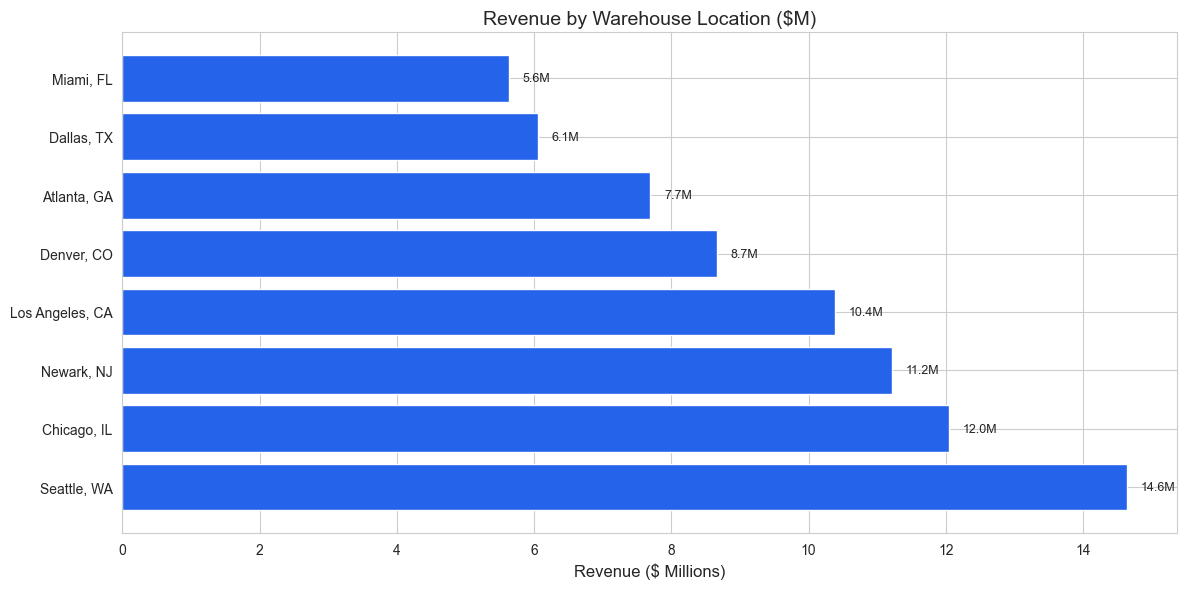

,Revenue,Orders,On_Time_Rate,Avg_Lead_Time
Warehouse_Location,,,,
"Seattle, WA",14641626.9,246,64.6,37.2
"Chicago, IL",12040418.4,248,61.7,34.8
"Newark, NJ",11214991.6,239,62.8,36.9
"Los Angeles, CA",10387516.3,249,68.3,35.1
"Denver, CO",8665310.8,275,59.6,38.0
"Atlanta, GA",7694420.3,254,68.1,35.8
"Dallas, TX",6054804.4,238,65.1,35.8
"Miami, FL",5633149.8,251,68.9,35.0


In [13]:
## 4b. Warehouse Performance

wh_perf = df.groupby('Warehouse_Location').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('Order_ID', 'count'),
    On_Time_Rate=('Delivery_Status', lambda x: (x == 'On Time').mean() * 100),
    Avg_Lead_Time=('Lead_Time_Days', 'mean')
).round(1).sort_values('Revenue', ascending=False)

fig, ax1 = plt.subplots()
bars = ax1.barh(wh_perf.index, wh_perf['Revenue'] / 1e6, color='#2563EB', edgecolor='white')
ax1.set_title('Revenue by Warehouse Location ($M)')
ax1.set_xlabel('Revenue ($ Millions)')
for bar, v in zip(bars, wh_perf['Revenue']):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f'{v/1e6:.1f}M', va='center', fontsize=9)
plt.tight_layout(); plt.savefig('../visuals/warehouse_performance.png', dpi=150, bbox_inches='tight'); plt.show()

wh_perf

---
## 5. Correlation Analysis

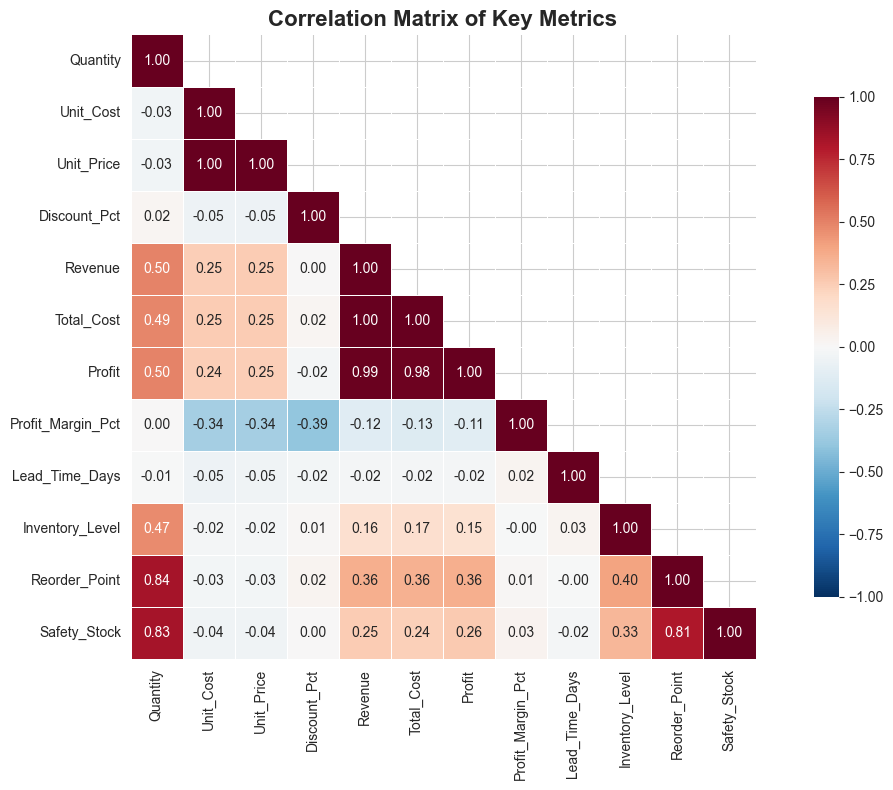

In [14]:
## 5a. Numeric Correlation Heatmap

numeric_cols = ['Quantity', 'Unit_Cost', 'Unit_Price', 'Discount_Pct', 'Revenue', 'Total_Cost', 'Profit',
                'Profit_Margin_Pct', 'Lead_Time_Days', 'Inventory_Level', 'Reorder_Point', 'Safety_Stock']
corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Key Metrics', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig('../visuals/correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 6. Key Insights & Recommendations

### Business Insights

1. **Network Equipment dominates revenue** at **43.3%** with high margins (~43%). This is the core profit engine and should be prioritized for supply chain reliability.
2. **SIM Cards and Fiber Cables** have the highest margins (48-49%) but contribute only **4.1% and 6.1% of revenue** respectively. These are high-value add-on sales opportunities.
3. **On-time delivery is only 65%** — nearly a third of orders face delays or damage. This severely impacts customer trust and incurs ~$21M in at-risk revenue.
4. **Direct Sales** yield the highest margin (47.8%) while **Retail Partners** have the lowest (35.5%). Channel strategy should favor Direct for high-value deals.
5. **Asian suppliers** have the longest lead times (avg 29 days). A dual-sourcing strategy with European/North American suppliers could reduce risk.
6. **Discounts above 15% erode margins by ~15 percentage points** vs no-discount orders. Discount tiers need stricter governance.
7. **Government segment** shows the highest margins (45.7%) — targeting public-sector contracts with dedicated SLAs could boost profitability.

### Actionable Recommendations

| # | Recommendation | Expected Impact | Timeline |
|---|---------------|----------------|----------|
| 1 | Implement supplier scorecard with lead-time SLAs for Asian suppliers | Reduce avg lead time by 30% | Q3 |
| 2 | Launch "Direct Sales Accelerator" program for high-value Enterprise deals | Increase margin by 3-5% | Q3 |
| 3 | Review and tighten discount approval workflow (>10% requires manager sign-off) | Recover 2-3% margin across discounted deals | Immediate |
| 4 | Increase safety stock for Battery/Power products (57% on-time rate) | Improve on-time delivery by 15% | Q4 |
| 5 | Add regional fulfillment centers near high-demand warehouses (Atlanta, Dallas) | Reduce lead time by 5-7 days | Q1 next year |
| 6 | Bundle SIM cards/Fiber with Network Equipment orders as upsells | Increase revenue per order by 8-12% | Q4 |

---
*Project completed as part of a data analysis portfolio. Data is synthetically generated but modeled on real industry patterns.*